In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import SimpleITK as sitk
import numpy as np
import pathlib
import seaborn as sns

In [2]:
manifest_path = "/home/furkan/projects/mebar-radiology/data/manifest.csv"
manifest_df = pd.read_csv(manifest_path)

## Tumor Volume Distribution

We need the histogram of tumor volume, compared between modalities ADC and T2.

In [3]:
def get_abs_path(relative_path):
    root_dir = pathlib.Path.cwd().parent
    return root_dir / relative_path

def get_tumor_volume(mask_path, debug=False):

    mask_image = sitk.ReadImage(mask_path)

    mask_array = sitk.GetArrayFromImage(mask_image)

    voxel_count = np.count_nonzero(mask_array)


    spacing = mask_image.GetSpacing()


    voxel_volume = spacing[0] * spacing[1] * spacing[2]


    volume = voxel_count * voxel_volume

    if debug:
        print("voxel count: ", voxel_count)
        print("voxel dimensions: ", spacing)
        print("voxel volume: ", voxel_volume)
        print("tumor volume: ", volume)
    
    return volume

In [ ]:
# Reminder: you analyzed this sample especially because it has 
# abnormally huge tumor volume
get_tumor_volume(get_abs_path(manifest_df[manifest_df["sample_id"] == "a158dd0f42dcd1d2"]["mask_path"]), debug=True)

voxel count:  88264
voxel dimensions:  (0.9375, 0.9375000000000004, 6.000000141583857, 1.0)
voxel volume:  5.273437624438939
tumor volume:  465454.6984834785


np.float64(465454.6984834785)

In [5]:
volume_df = manifest_df[
    ["sample_id", "mask_path", "modality", "response_group",
    'image_shape_x','image_shape_y', 'image_shape_z',
    'image_spacing_x_mm', 'image_spacing_y_mm', 'image_spacing_z_mm']]
volume_df.head()

,sample_id,mask_path,modality,response_group,image_shape_x,image_shape_y,image_shape_z,image_spacing_x_mm,image_spacing_y_mm,image_spacing_z_mm
0,0d6f73a01539ae0d,"data/raw/batch-1/İNTERMEDİATE/ABDULLAEVA, GU...",ADC,intermediate,224,224,45,1.785714,1.785714,6.600000
1,85388bd87a565011,"data/raw/batch-1/İNTERMEDİATE/ABDULLAEVA, GU...",T2,intermediate,352,352,24,0.397727,0.397727,3.500000
2,c5574c732708c9c0,"data/raw/batch-1/İNTERMEDİATE/AKKAYA, HATICE...",ADC,intermediate,128,256,20,0.781250,0.781250,3.600031
3,d4e511f387bc2059,"data/raw/batch-1/İNTERMEDİATE/AKKAYA, HATICE...",T2,intermediate,336,336,20,0.595238,0.595238,3.600029
4,85e3e9f712fe9029,"data/raw/batch-1/İNTERMEDİATE/ARSLAN, AYSEL/...",ADC,intermediate,224,224,36,1.785714,1.785714,6.600000


In [6]:
for idx, row in volume_df.iterrows():
    abs_mask_path = get_abs_path(row["mask_path"])
    tumor_volume = get_tumor_volume(abs_mask_path)
    volume_df.at[idx, "tumor_volume"] = tumor_volume

In [7]:
volume_df.head()

,sample_id,mask_path,modality,response_group,image_shape_x,image_shape_y,image_shape_z,image_spacing_x_mm,image_spacing_y_mm,image_spacing_z_mm,tumor_volume
0,0d6f73a01539ae0d,"data/raw/batch-1/İNTERMEDİATE/ABDULLAEVA, GU...",ADC,intermediate,224,224,45,1.785714,1.785714,6.600000,9849.489232
1,85388bd87a565011,"data/raw/batch-1/İNTERMEDİATE/ABDULLAEVA, GU...",T2,intermediate,352,352,24,0.397727,0.397727,3.500000,10016.716051
2,c5574c732708c9c0,"data/raw/batch-1/İNTERMEDİATE/AKKAYA, HATICE...",ADC,intermediate,128,256,20,0.781250,0.781250,3.600031,12025.738329
3,d4e511f387bc2059,"data/raw/batch-1/İNTERMEDİATE/AKKAYA, HATICE...",T2,intermediate,336,336,20,0.595238,0.595238,3.600029,17410.850118
4,85e3e9f712fe9029,"data/raw/batch-1/İNTERMEDİATE/ARSLAN, AYSEL/...",ADC,intermediate,224,224,36,1.785714,1.785714,6.600000,7913.264802


In [8]:
volume_df.describe()

,image_shape_x,image_shape_y,image_shape_z,image_spacing_x_mm,image_spacing_y_mm,image_spacing_z_mm,tumor_volume
count,376.000000,376.000000,376.000000,376.000000,376.000000,376.000000,376.000000
mean,318.622340,330.611702,32.670213,0.933001,0.933001,4.340751,24182.127481
std,162.785441,151.499802,7.271700,0.521825,0.521825,1.502052,36819.147311
min,96.000000,96.000000,15.000000,0.271739,0.271739,2.999975,1428.217433
25%,224.000000,224.000000,26.000000,0.397727,0.397727,3.000000,7833.994662
50%,304.000000,287.000000,34.000000,0.819672,0.819672,3.599993,14117.568187
75%,400.000000,400.000000,36.000000,1.388889,1.388889,6.000001,24665.654135
max,768.000000,768.000000,65.000000,1.979167,1.979167,9.227272,465454.698483


### Detect Outliers

In [ ]:
# largest n volume
idx = volume_df["tumor_volume"].nlargest(10).index
volume_df.iloc[idx]

,sample_id,mask_path,modality,response_group,image_shape_x,image_shape_y,image_shape_z,image_spacing_x_mm,image_spacing_y_mm,image_spacing_z_mm,tumor_volume
97,a158dd0f42dcd1d2,"data/raw/batch-1/NONRESPONDER/MASOUD, ABDULNAB...",T2,nonresponder,480,480,65,0.937500,0.937500,6.0,465454.698483
96,61640251fdc38baa,"data/raw/batch-1/NONRESPONDER/MASOUD, ABDULNAB...",ADC,nonresponder,192,192,30,1.953125,1.953125,5.0,322475.420439
235,fa0a3977546b3239,"data/raw/batch-2/INTERMEDIATE/ORUC, SULTAN/T2/...",T2,intermediate,480,480,36,0.833333,0.833333,6.6,152666.242438
91,2b498ea42b97db7e,"data/raw/batch-1/NONRESPONDER/ICLI, GURCAN/T2/...",T2,nonresponder,528,528,24,0.340909,0.340909,3.5,151764.592335
195,e839228dc052fb77,"data/raw/batch-1/RESPONDER/UNUSDU, MIRZE/T2/Se...",T2,responder,400,400,36,1.000000,1.000000,6.6,142883.395281
234,56ffefde400cefd3,"data/raw/batch-2/INTERMEDIATE/ORUC, SULTAN/ADC...",ADC,intermediate,224,224,36,1.785714,1.785714,6.6,138040.175683
194,6e66c48e0aeeff05,"data/raw/batch-1/RESPONDER/UNUSDU, MIRZE/ADC/S...",ADC,responder,224,224,36,1.785714,1.785714,6.6,129516.574885
158,b2539e991aa1743f,"data/raw/batch-1/RESPONDER/GULLU, MIYESE/ADC/S...",ADC,responder,224,224,36,1.785714,1.785714,6.6,109102.034231
90,ade05365b0b2fe7a,"data/raw/batch-1/NONRESPONDER/ICLI, GURCAN/ADC...",ADC,nonresponder,256,256,50,1.562500,1.562500,4.0,103193.362311
260,c79b2678007b3a37,"data/raw/batch-2/NONRESPONDER/KARAKUS, ADISIN/...",ADC,nonresponder,240,240,40,1.666667,1.666667,6.0,101983.327624


In [ ]:
# largest n volume for larger n values
# spaced with a step_size, for a wider perspective

n = 50
step_size = 5

top_n_idx = volume_df["tumor_volume"].nlargest(n).index
idx = []
for start in range(0, n, step_size):
    idx.append(top_n_idx[start])

stepped = volume_df.iloc[idx]
stepped["order"] = [step+1 for step in list(range(0, n, step_size))]

stepped

,sample_id,mask_path,modality,response_group,image_shape_x,image_shape_y,image_shape_z,image_spacing_x_mm,image_spacing_y_mm,image_spacing_z_mm,tumor_volume,order
97,a158dd0f42dcd1d2,"data/raw/batch-1/NONRESPONDER/MASOUD, ABDULNAB...",T2,nonresponder,480,480,65,0.937500,0.937500,6.000000,465454.698483,1
234,56ffefde400cefd3,"data/raw/batch-2/INTERMEDIATE/ORUC, SULTAN/ADC...",ADC,intermediate,224,224,36,1.785714,1.785714,6.600000,138040.175683,6
192,4edd6151781a381c,"data/raw/batch-1/RESPONDER/TURKOGLU, IBRAHIM/A...",ADC,responder,224,224,36,1.785714,1.785714,6.600000,99589.282333,11
307,299082091eee4a23,"data/raw/batch-2/RESPONDER/CHAKAROV, DANCHO AN...",T2,responder,352,352,30,0.397727,0.397727,4.000000,92093.937947,16
154,d83db68c204da2a1,"data/raw/batch-1/RESPONDER/GOK, AYTEN/ADC/Segm...",ADC,responder,224,224,36,1.785714,1.785714,6.600000,67999.362792,21
121,691429e21e800123,"data/raw/batch-1/NONRESPONDER/YALCINKAYA, ILHA...",T2,nonresponder,336,336,34,0.595238,0.595238,3.599983,63313.463963,26
261,e0cc756fd0e62afb,"data/raw/batch-2/NONRESPONDER/KARAKUS, ADISIN/...",T2,nonresponder,512,512,35,0.669643,0.669643,7.000000,58327.986892,31
78,5b88858f09c78160,"data/raw/batch-1/NONRESPONDER/ATES, HAMIDE/ADC...",ADC,nonresponder,224,224,36,1.785714,1.785714,6.600000,54109.055090,36
120,827e7e767c078596,"data/raw/batch-1/NONRESPONDER/YALCINKAYA, ILHA...",ADC,nonresponder,128,256,34,0.781250,0.781250,3.599984,51639.900792,41
320,06d132af4f67d3c8,"data/raw/batch-2/RESPONDER/GUBAREV, RUSLAN/ADC...",ADC,responder,128,256,39,0.781250,0.781250,3.600013,45786.786795,46


### As Boxplot (without outliers)

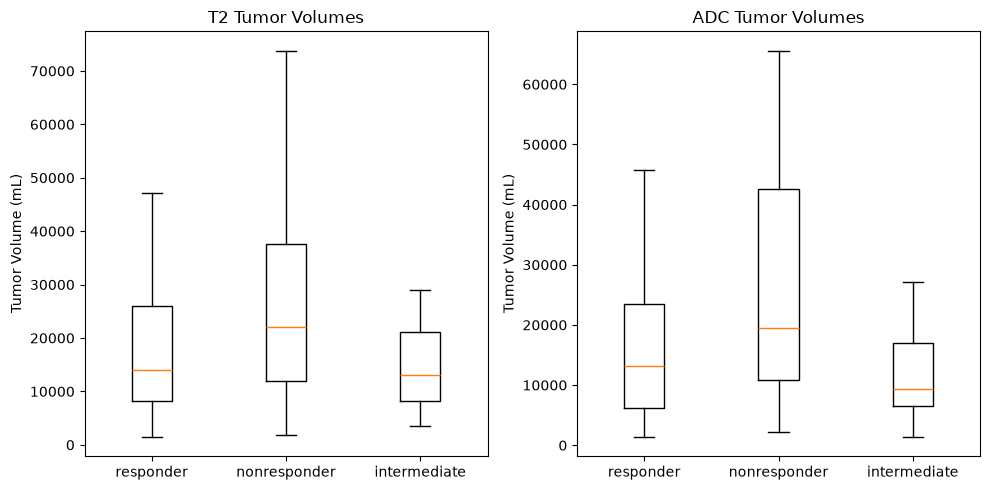

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

groups = ["responder", "nonresponder", "intermediate"]

# T2
t2_volumes = [
    volume_df[
        (volume_df["modality"] == "T2") &
        (volume_df["response_group"] == group)
    ]["tumor_volume"].dropna()
    for group in groups
]

axes[0].boxplot(
    t2_volumes,
    tick_labels=groups,
    showfliers=False
)
axes[0].set_title("T2 Tumor Volumes")
axes[0].set_ylabel("Tumor Volume (mL)")


# ADC
adc_volumes = [
    volume_df[
        (volume_df["modality"] == "ADC") &
        (volume_df["response_group"] == group)
    ]["tumor_volume"].dropna()
    for group in groups
]

axes[1].boxplot(
    adc_volumes,
    tick_labels=groups,
    showfliers=False
)
axes[1].set_title("ADC Tumor Volumes")
axes[1].set_ylabel("Tumor Volume (mL)")

plt.tight_layout()
plt.show()

### As Kernel Density Estimate (Without Outliers)

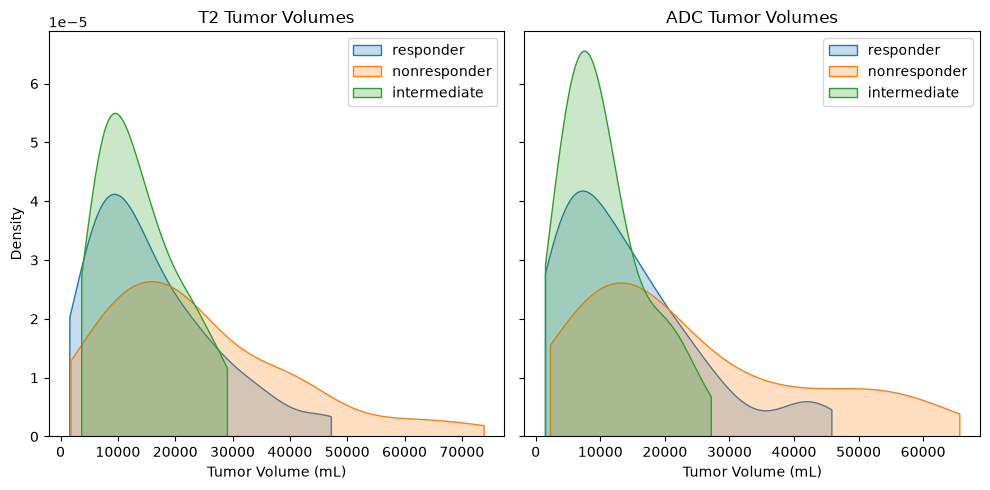

In [12]:
def remove_outliers_iqr(
    values,
    ):
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return values[values.between(lower, upper)]


fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

groups = ["responder", "nonresponder", "intermediate"]

for ax, modality in zip(axes, ["T2", "ADC"]):
    subset = volume_df[
        (volume_df["modality"] == modality) &
        volume_df["tumor_volume"].notna()
    ]

    for group in groups:
        volumes = subset.loc[
            subset["response_group"] == group,
            "tumor_volume"
        ]

        filtered = remove_outliers_iqr(volumes)

        sns.kdeplot(
            x=filtered,
            label=group,
            fill=True,
            alpha=0.25,
            cut=0,             # Eğrinin negatif hacimlere uzamasını önler
            common_norm=False,
            ax=ax
        )

    ax.set_title(f"{modality} Tumor Volumes")
    ax.set_xlabel("Tumor Volume (mL)")
    ax.set_ylabel("Density")
    ax.legend()


plt.tight_layout()
plt.show()

**CONCLUSION:** Tumor volumes are changing drastically, processing whole MRI probably would result bad. Instead, cropping only tumor area might eliminate the huge differentiation of size of background data among samples, model should focus only on tumor. However, a **margin** is necessary for model to learn not only tumor area, but also it's effect on the tissue around it.

At the worst scenario, if we realize differentiation among samples negatively affects the model learning, **we might only use closer samples, a subset appox. 50% of the dataset.**